In [1]:
# Dataset and data root config

dataset = 'mlc25'
data_root = './data'

In [2]:
import numpy as np

def mean_euclidean_error(y_true, y_pred):
    # Calculate the difference between true and predicted values
    diff = y_true - y_pred
    
    # Reshapes row vectors to column vectors for consistent norm calculation
    if diff.ndim == 1:
        diff = diff.reshape(-1, 1)

    # Calculate mean Euclidean error
    return np.linalg.norm(diff, axis=1).mean()

In [3]:
from sklearn.metrics import make_scorer

# Create a scorer for use in model evaluation
mee_scorer = make_scorer(mean_euclidean_error, greater_is_better=False)

In [5]:
# === 2. IMPORTS AND UTILITIES ===
from utils.data_loader import get_monk1_data, get_ml_cup_data  
from torch.utils.data import DataLoader, TensorDataset
from models import SVCModel, SVRModel
from sklearn.metrics import *
from sklearn.multioutput import MultiOutputRegressor
  
    
# --- Utility function to extract data from DataLoader to NumPy arrays ---
def extract_data_to_numpy(data_loader):
    """
    Converts data from a PyTorch DataLoader into a flattened NumPy array pair (X, y).
    Targets (y) are returned in their original dimensionality (e.g., [N, M] for multi-output).
    """
    X_list = []
    y_list = []
    for X, y in data_loader:
        # Flatten the input (e.g., 28x28 image -> 784 features)
        X_list.append(X.view(X.size(0), -1).numpy()) 
        # Convert labels to NumPy
        y_list.append(y.numpy())
    
    X_data = np.concatenate(X_list)
    y_data = np.concatenate(y_list)
    
    # We return y_data as is (2D array, e.g., [N, 1] or [N, M]).
    return X_data, y_data

In [6]:
from sklearn.preprocessing import StandardScaler

# Use StandardScaler for feature scaling with 0 mean and unit variance
scaler = StandardScaler()

In [7]:
# === 3. DATA LOADING AND PREPARATION ===

from utils.data_loader import get_monk1_data, get_ml_cup_data
import sys

dataset_name = dataset
BATCH_SIZE = 1024 # Batch size for DataLoader (not used in SVM but for consistency) 

print(f"Loading dataset: {dataset_name.upper()}...")
    
# Determine task type and load data (DataLoader objects are returned)
if dataset_name == 'monk1':
    train_loader, test_loader, INPUT_SIZE, OUTPUT_SIZE = get_monk1_data(BATCH_SIZE, data_root)
    is_regression_task = False
    metric_name = "Test Accuracy (%)"

elif dataset_name == 'mlc25':
    train_loader, test_loader = get_ml_cup_data(BATCH_SIZE, data_root, test_ratio = 0.25, mps = False,scaler = scaler)
    is_regression_task = True
    metric_name = "Test MEE"

else:
    # This block handles the error if the dataset is outside the specified choices (monk1, mlc25).
    print("Unsupported dataset for SVM.")
    sys.exit(1)


# --- 3.2 Data Preparation for Scikit-learn ---

# Convert DataLoaders (PyTorch) to NumPy arrays (Scikit-learn)
X_train, y_train = extract_data_to_numpy(train_loader)
X_test, y_test = extract_data_to_numpy(test_loader)

print(f"Data loaded: Training samples={X_train.shape[0]}, Test samples={X_test.shape[0]}")

Loading dataset: MLC25...
applying scaling StandardScaler on train_X and test_X
Data loaded: Training samples=375, Test samples=125


In [8]:
# Verify shapes

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((375, 12), (375, 4), (125, 12), (125, 4))

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, KFold
from sklearn.svm import SVC, SVR
from scipy.stats import loguniform

# 1. Definition of parameters in common for both SVC and SVR
common_params = [
    # 1. Linear Kernel: C is the ONLY parameter. Gamma is implicitly 'scale' or ignored.
    {
        'kernel': ['linear'],
        'C': loguniform(1e-3, 1e2),
    },
    
    # 2. RBF/Poly Kernels with Discrete Gamma: Tests the two known heuristics.
    {
        'kernel': ['rbf', 'poly'],
        'C': loguniform(1e-3, 1e2),
        'gamma': ['scale', 'auto'], # Discrete strings only
    },
    
    # 3. RBF/Poly Kernels with Continuous Gamma: Randomly samples from the continuous range.
    {
        'kernel': ['rbf', 'poly'],
        'C': loguniform(1e-3, 1e2),
        'gamma': loguniform(1e-3, 1e1), # Continuous distribution object only
    },
]

# 2. Conditional logic for epsilon parameter in SVR
if is_regression_task:
    params = []
    for p in common_params:
        p_new = p.copy()
        p_new['epsilon'] = loguniform(1e-2,1e1)
        params.append(p_new)  # Append modified copy for SVR
    
    print("SVR parameters with epsilon added.")

else:
    params = common_params
    print("SVC parameters without epsilon.")


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) if not is_regression_task else KFold(n_splits=5, shuffle=True, random_state=42)  

SVR parameters with epsilon added.


In [10]:
# HP Randomized Search Configuration

limit = 100000
size = 1000

# Max iter and cache size set for efficiency
base_estimator = SVC(max_iter=limit, cache_size=size) if not is_regression_task \
            else SVR(max_iter=limit, cache_size=size)

hp_search = RandomizedSearchCV(
    estimator = base_estimator,
    param_distributions = params,
    n_iter = 50,                     # Number of random configurations to try
    scoring = 'accuracy' if not is_regression_task else mee_scorer,
    cv = kfold, 
    n_jobs = -1,
    verbose = 1)                          


In [11]:
if is_regression_task:
    # Wrap in MultiOutputRegressor if the dataset is mlc25
    final_model = MultiOutputRegressor(hp_search)  
else:
    final_model = hp_search

In [12]:
final_model.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/alexo41/mi

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/alexo41/miniconda3/envs/raml_env/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/alexo41/mi

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,RandomizedSea... verbose=1)
,n_jobs,None
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,1000


In [13]:
if is_regression_task:
    # Print estimators for each output if mlc25
    print(final_model.estimators_)
else:
    print(final_model.best_params_)
    

[RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=SVR(cache_size=1000, max_iter=100000), n_iter=50,
                   n_jobs=-1,
                   param_distributions=[{'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7bc75ced1ea0>,
                                         'epsilon': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7bc80f607d60>,
                                         'kernel': ['linear']}...
                                        {'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7bc75df7b670>,
                                         'epsilon': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7bc75df7b910>,
                                         'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7bc75df7bf40>,
                                         'kernel': ['rbf', 'poly']}],
                   sc

In [14]:
# === 4. MODEL INITIALIZATION (FINAL RECONSTRUCTION) ===

# --- 4.0 Helper Function to Create Wrapper from Estimator ---
def create_model_from_estimator(best_estimator):
    """
    Extracts parameters from the best_estimator and creates an instance
    of the following custom wrapper (SVCModel or SVRModel).
    """
    # 1. Get parameters from the fitted model
    params = best_estimator.get_params()
    
    # 2. Determine the type and instantiate the correct wrapper
    if isinstance(best_estimator, SVC):
        return SVCModel(**params), 'svc'
    elif isinstance(best_estimator, SVR):
        return SVRModel(**params), 'svr'
    else:
        raise TypeError(f"Type unsupported for reconstruction: {type(best_estimator)}")

In [15]:
# --- 4.1 Reconstruction Logic ---

final_models_list = []  # List to hold final model wrappers
is_multi_output = False # Flag to indicate multi-output scenario

# MLC25 case: check if final_model has 'estimators_' attribute typical of MultiOutput wrapper
if hasattr(final_model, 'estimators_'):
    print(f"Detected Multi-Output System ({len(final_model.estimators_)} targets).")
    is_multi_output = True
    
    # Iterate over each RandomizedSearchCV contained in the MultiOutput
    for i, search_obj in enumerate(final_model.estimators_):
        # Extract the winner for this specific target
        best_est = search_obj.best_estimator_
        
        # Create wrapper
        wrapper, m_type = create_model_from_estimator(best_est)
        final_models_list.append(wrapper)
        
        print(f"Target {i}: Configured {m_type.upper()} with C={wrapper.model.C:.4f}, gamma={wrapper.model.gamma}, epsilon={getattr(wrapper.model, 'epsilon', 'N/A')}")

# MONK1 case: Single Output
else:
    print("Detected Single-Output System.")
    # final_model is directly the RandomizedSearchCV
    best_est = final_model.best_estimator_
    
    wrapper, m_type = create_model_from_estimator(best_est)
    final_models_list.append(wrapper)
    
    print(f"Configured {m_type.upper()} with C={wrapper.model.C:.4f}, gamma={wrapper.model.gamma}")

Detected Multi-Output System (4 targets).
Target 0: Configured SVR with C=27.0648, gamma=scale, epsilon=4.418401499000089
Target 1: Configured SVR with C=10.2046, gamma=0.3085338744175357, epsilon=1.810680537471794
Target 2: Configured SVR with C=47.7292, gamma=2.963030735331485, epsilon=3.539952013287808
Target 3: Configured SVR with C=0.2172, gamma=scale, epsilon=18.671826877346884


In [16]:
# --- 4.2 Final Fitting and Prediction ---

print("\n--- Starting Final Refitting of Models ---")

if is_multi_output:
    for i, wrapper in enumerate(final_models_list):
        print(f"Fitting Target {i}...")
        # Note: y_train[:, i] takes only the i-th column
        wrapper.fit(X_train, y_train[:, i]) 
        
else:
    print("Fitting Single Model...")
    final_models_list[0].fit(X_train, y_train.ravel())

print("Refitting done.")


--- Starting Final Refitting of Models ---
Fitting Target 0...
Fitting Target 1...
Fitting Target 2...
Fitting Target 3...
Refitting done.


In [17]:
# === 6. PREDICTION & EVALUATION ===

# 6.1 Generation of Predictions (Handles List vs Single Model Case)
print("\n--- Generating Predictions ---")

if is_multi_output:
    # Multi-Output Case: Iterate over the list of models
    column_preds = []
    for wrapper in final_models_list:
        pred = wrapper.predict(X_test)
        column_preds.append(pred)
    
    # Combine columns: (N_samples, N_targets)
    y_test_pred = np.column_stack(column_preds)
    
    y_test_eval = y_test 
    
else:
    # Single Output Case: Directly use the single model
    y_test_pred = final_models_list[0].predict(X_test)
    
    # Flatten y_test for comparison
    y_test_eval = y_test.ravel()

# Ensure y_test is in the correct shape for comparison
print(f"Predictions generated. Shape: {y_test_pred.shape}")


--- Generating Predictions ---
Predictions generated. Shape: (125, 4)


In [18]:
# 6.2 Calculating Metrics

print("\n--- Calculating Metrics ---")

if is_regression_task:
    # Calculate MEE for Regression
    final_metric = mean_euclidean_error(y_test_eval, y_test_pred)
else:
    # Calculate Accuracy for Classification
    final_metric = accuracy_score(y_test_eval, y_test_pred) * 100.0
    
# 6.3 Risultato Finale
print(f"Final {metric_name}: {final_metric}")


--- Calculating Metrics ---
Final Test MEE: 21.268044980404948


In [19]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import make_scorer

if is_regression_task:
    # 1. Define dummy model
    # strategy='mean' predicts always the mean of the training set for each target
    dummy_regr = DummyRegressor(strategy="mean")

    # 2. Training (just computes means, it's instantaneous)
    print("\n--- Training Baseline (Dummy Regressor) ---")
    dummy_regr.fit(X_train, y_train)

    # 3. Prediction
    y_pred_dummy = dummy_regr.predict(X_test)

    # 4. Baseline MEE Calculation
    mee_baseline = mean_euclidean_error(y_test, y_pred_dummy)

    print(f"Baseline MEE (Mean Strategy): {mee_baseline:.4f}")
    print(f"Best SVR model MEE:          {final_metric:.4f}") 

    # 5. Comparison
    if final_metric < mee_baseline:
        print("SUCCESS: the model outperforms the baseline!")
        improvement = mee_baseline - final_metric
        print(f"   Improvement: {improvement:.4f} MEE points")
    else:
        print("FAIL: the model is worse than the baseline.")


--- Training Baseline (Dummy Regressor) ---
Baseline MEE (Mean Strategy): 36.1364
Best SVR model MEE:          21.2680
SUCCESS: the model outperforms the baseline!
   Improvement: 14.8684 MEE points


In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

if not is_regression_task:
    print("\n--- Training Baseline (Dummy Classifier) ---")
    
    # 1. Define dummy model
    # strategy='most_frequent' always predicts the most frequent class in the training set
    dummy_clf = DummyClassifier(strategy="most_frequent")
    
    # 2. Training 
    dummy_clf.fit(X_train, y_train.ravel())
    
    # 3. Prediction
    y_pred_dummy = dummy_clf.predict(X_test)
    
    # 4. Baseline Accuracy Calculation
    acc_baseline = accuracy_score(y_test.ravel(), y_pred_dummy) * 100.0
    
    print(f"Baseline Accuracy (Most Frequent): {acc_baseline:.2f}%")
    print(f"Best SVC model Accuracy:          {final_metric:.2f}%") 
    
    # 5. Comparison
    if final_metric > acc_baseline:
        print("SUCCESS: the model outperforms the baseline!")
        print(f"   Improvement: +{final_metric - acc_baseline:.2f}%")
    else:
        print("FAIL: the model is worse than the baseline.")

# CORREGGERE DA QUI IN POI


In [21]:
import os
import json
import datetime

def save_model_system(models_list, dataset_name, is_regression, base_dir='./svm_saved_models', model_tag="Best_Model"):
    """
    Gestisce il salvataggio strutturato di modelli e registri JSON.
    """
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # 1. Definiamo i percorsi base
    if is_regression:
        task_folder = os.path.join(base_dir, "regression")
        registry_file = os.path.join(task_folder, "regression_registry.json")
        # Per la regressione, creiamo una sottocartella specifica per QUESTO run di modelli
        run_name = f"{dataset_name}_{model_tag}_{timestamp}"
        save_path_root = os.path.join(task_folder, run_name)
    else:
        task_folder = os.path.join(base_dir, "classificaton")
        registry_file = os.path.join(task_folder, "classification_registry.json")
        # Per la classificazione, i file vanno direttamente nella cartella classificazione
        save_path_root = task_folder 

    os.makedirs(save_path_root, exist_ok=True)
    
    # 2. Carichiamo (o creiamo) il Registro JSON
    registry = {}
    if os.path.exists(registry_file):
        try:
            with open(registry_file, 'r') as f:
                registry = json.load(f)
        except json.JSONDecodeError:
            print("Warning: Registro JSON corrotto, ne creo uno nuovo.")
    
    # 3. Logica di Salvataggio Differenziata
    entry_key = f"{dataset_name}_{model_tag}_{timestamp}"
    
    if is_regression:
        # === CASO MULTI-OUTPUT (ML-CUP) ===
        print(f"📁 Saving Regression System to: {save_path_root}")
        
        target_configs = {}
        
        for i, wrapper in enumerate(models_list):
            # A. Salva il PKL nella sottocartella
            filename = f"target_{i}.pkl"
            full_path = os.path.join(save_path_root, filename)
            wrapper.save_pkl(full_path)
            
            # B. Raccogli i parametri per il JSON
            target_configs[f"target_{i}"] = wrapper.get_params_clean()
        
        # C. Aggiorna il Registro Unico
        registry[entry_key] = {
            "type": "MultiOutput SVR",
            "timestamp": timestamp,
            "location": save_path_root, # Percorso della cartella contenente i 4 file
            "targets": target_configs
        }

    else:
        # === CASO SINGLE-OUTPUT (MONK) ===
        print(f"📁 Saving Classification Model to: {save_path_root}")
        
        wrapper = models_list[0]
        
        # A. Salva il PKL (file singolo con nome univoco)
        filename = f"{entry_key}.pkl"
        full_path = os.path.join(save_path_root, filename)
        wrapper.save_pkl(full_path)
        
        # B. Aggiorna il Registro Unico
        registry[entry_key] = {
            "type": "SVC",
            "timestamp": timestamp,
            "filepath": full_path,
            "params": wrapper.get_params_clean()
        }

    # 4. Scrittura finale del Registro su disco
    with open(registry_file, 'w') as f:
        json.dump(registry, f, indent=4)
        
    print(f"📝 Registry updated: {registry_file}")

# --- ESECUZIONE ---
# Chiamata alla funzione (funziona sia per Monk che per MLCup grazie ai flag)
save_model_system(
    models_list=final_models_list, 
    dataset_name=dataset_name, 
    is_regression=is_regression_task,
    model_tag="SVR_Optimized" if is_regression_task else "SVC_Optimized"
)

📁 Saving Regression System to: ./svm_saved_models/regression/mlc25_SVR_Optimized_20251212_182322
📝 Registry updated: ./svm_saved_models/regression/regression_registry.json



--- Generating Learning Curves ---
Questa operazione richiede tempo perché ri-addestra i modelli su sotto-insiemi del dataset...

Generazione curva per Modello 0...


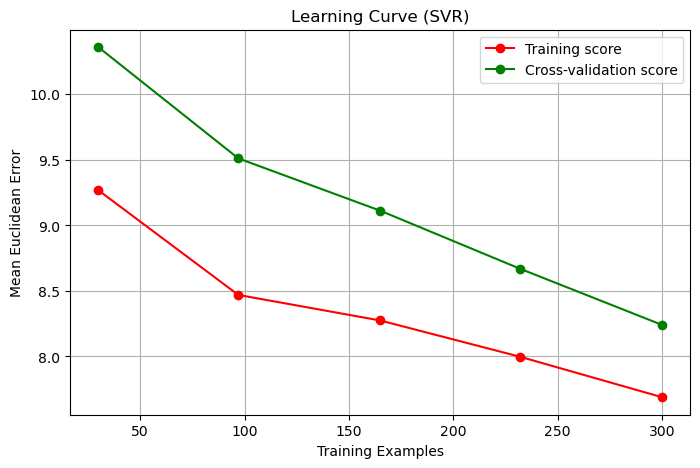


Generazione curva per Modello 1...


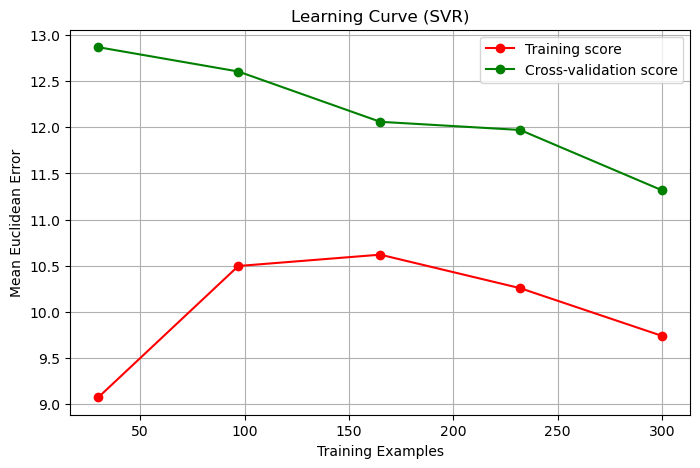


Generazione curva per Modello 2...


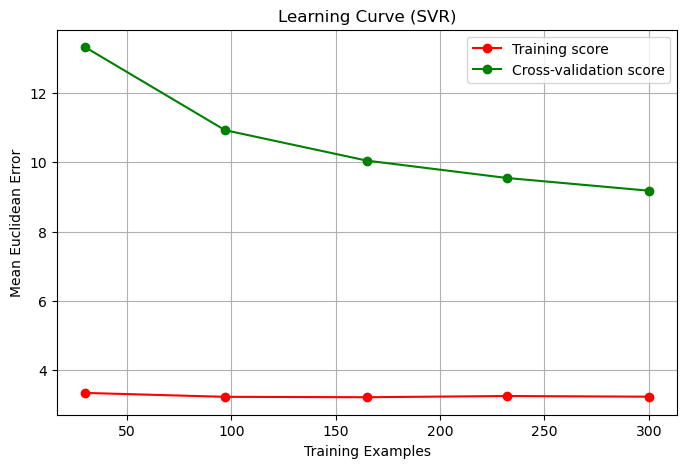


Generazione curva per Modello 3...


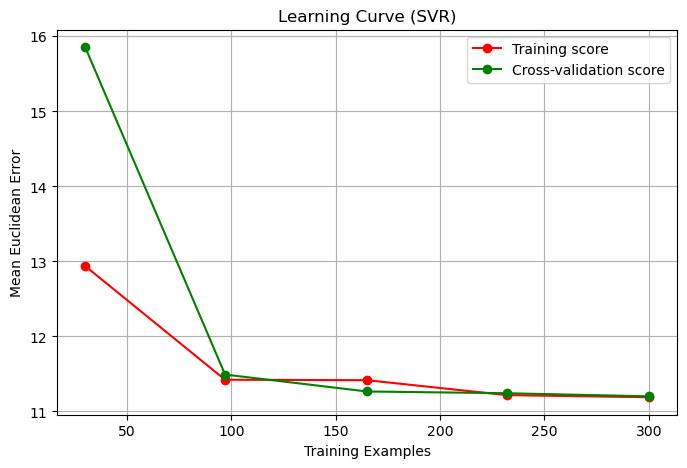


--- Done ---


In [22]:
# === LEARNING CURVE VISUALIZATION ===
import matplotlib.pyplot as plt

print("\n--- Generating Learning Curves ---")
print("Questa operazione richiede tempo perché ri-addestra i modelli su sotto-insiemi del dataset...")

# Determiniamo la metrica di scoring corretta
# Nota: Scikit-learn usa metriche "neg_" per gli errori (più alto è meglio, quindi -5 è meglio di -20)
if is_regression_task:
    # Per regressione usiamo l'errore assoluto negativo come proxy del MEE
    score_metric = mee_scorer 
else:
    # Per classificazione usiamo l'accuracy standard
    score_metric = 'accuracy'

# Ciclo sui modelli (1 per Monk, 4 per ML-CUP)
for i, wrapper in enumerate(final_models_list):
    print(f"\nGenerazione curva per Modello {i}...")
    
    # Selezioniamo la y corretta
    if is_regression_task:
        # Per ML-CUP prendiamo la colonna specifica i-esima
        current_y = y_train[:, i]
        title = f"Target {i} Learning Curve"
    else:
        # Per MONK usiamo ravel()
        current_y = y_train.ravel()
        title = "Monk-1 Classification Learning Curve"
        
    # Chiamiamo il metodo che abbiamo integrato nel wrapper
    # cv=5 significa che farà una Cross Validation a 5 fold per ogni punto del grafico
    wrapper.plot_learning_curve(X_train, current_y, cv=5, scoring=score_metric)

print("\n--- Done ---")


--- Generating Analysis Plots ---
Plotting Target 0...


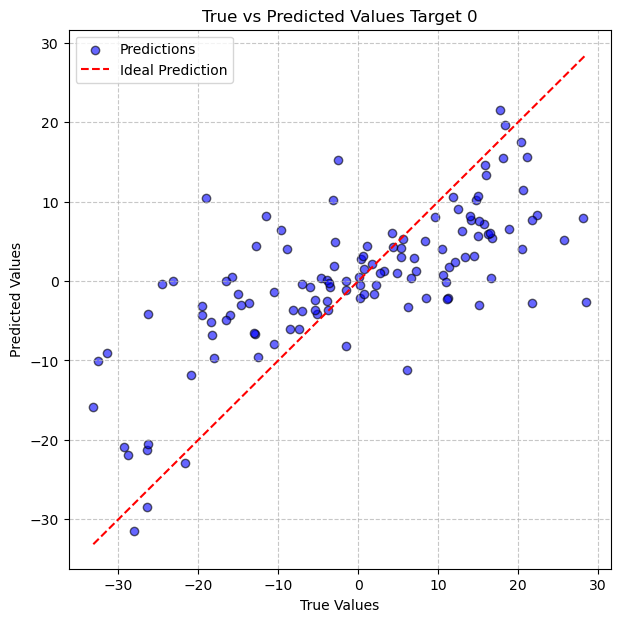

Plotting Target 1...


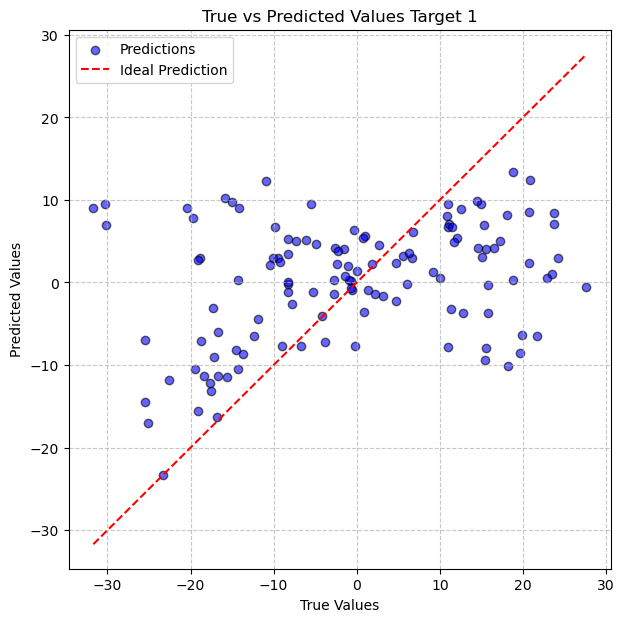

Plotting Target 2...


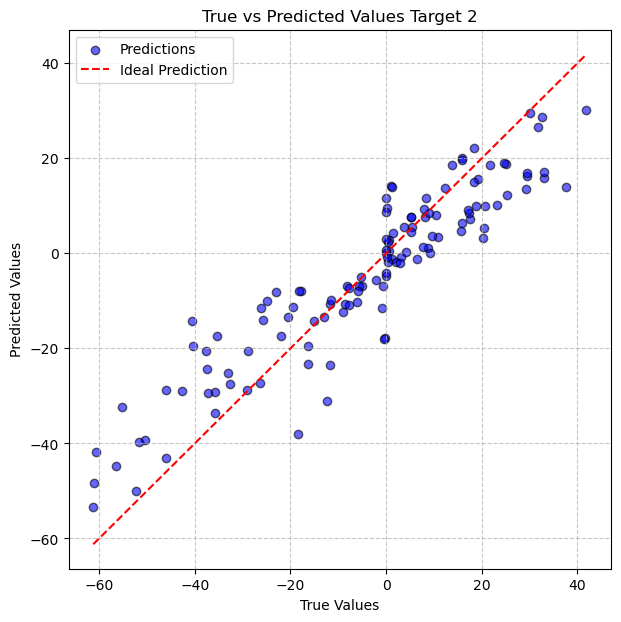

Plotting Target 3...


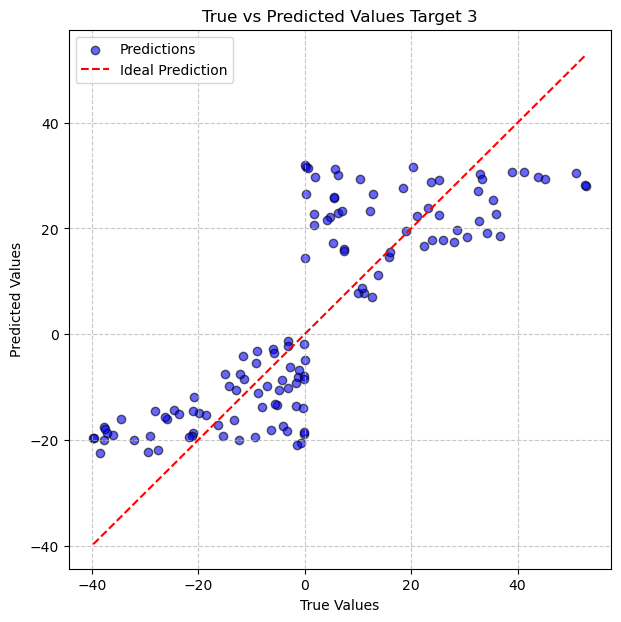

Visualizations complete.


In [23]:
# === 9. VISUALIZATIONS (INFERENCE ANALYSIS) ===
# Questa sezione genera i grafici usando i metodi integrati nei wrapper.

print("\n--- Generating Analysis Plots ---")

if is_regression_task:
    # --- CASO ML-CUP (Regressione) ---
    # Generiamo uno scatter plot per ogni target (4 totali)
    
    for i, wrapper in enumerate(final_models_list):
        print(f"Plotting Target {i}...")
        
        # Estraiamo la colonna corretta di y_test per questo target
        y_test_target = y_test[:, i]
        
        # Chiamiamo il metodo del wrapper SVRModel
        # Nota: Non serve passare y_pred, lo calcola lui internamente da X_test
        wrapper.plot_regression_analysis(X_test, y_test_target, title_suffix=f"Target {i}")

else:
    # --- CASO MONK (Classificazione) ---
    # Generiamo Confusion Matrix e ROC Curve
    print("Plotting Classification Analysis...")
    
    wrapper = final_models_list[0]
    
    # y_test è già la forma corretta (ravel o colonna)
    # Chiamiamo il metodo del wrapper SVCModel
    wrapper.plot_classification_analysis(X_test, y_test.ravel())

print("Visualizations complete.")